In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
train, _ = tfds.load('horses_or_humans', split=['train[:100%]'], with_info=True, as_supervised=True)

In [ ]:
SIZE = 224

tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)


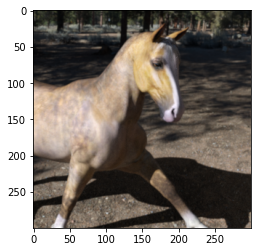

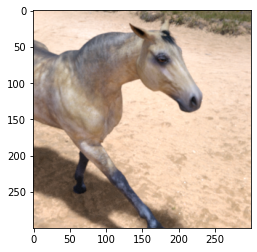

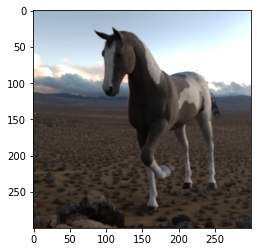

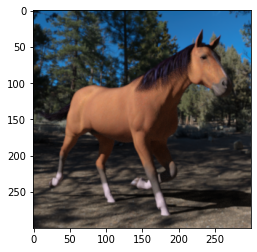

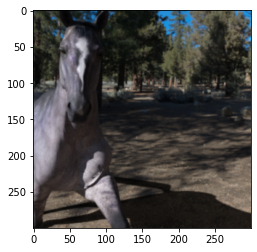

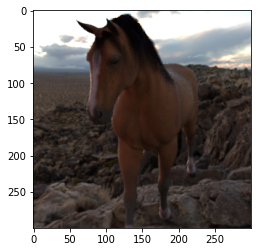

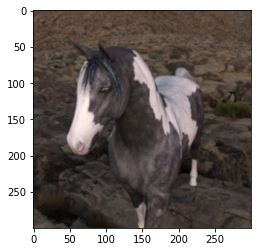

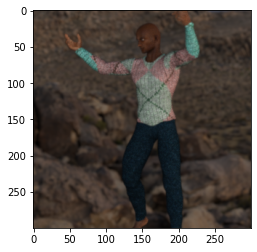

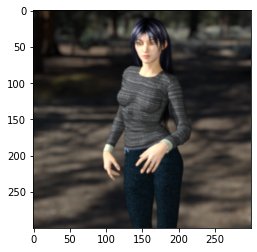

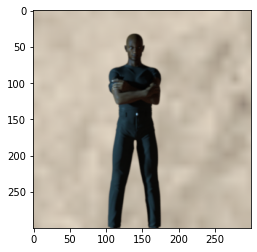

In [ ]:
for img, label in train[0].take(10):
  plt.figure()
  plt.imshow(img)
  print(label)

In [ ]:
def resize_image(img, label):
  img = tf.cast(img, tf.float32)
  img = tf.image.resize(img, (SIZE, SIZE))
  img = img / 255.0
  return img, label

In [ ]:
train_resized = train[0].map(resize_image)
train_batches = train_resized.shuffle(1000).batch(16)

In [ ]:
base_layers = tf.keras.applications.MobileNetV2(input_shape=(SIZE, SIZE, 3), include_top=False)
base_layers.trainable = False

In [ ]:
model = tf.keras.Sequential([
                             base_layers,
                             GlobalAveragePooling2D(),
                             Dropout(0.2),
                             Dense(1)
])
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])

In [ ]:
model.fit(train_batches, epochs=1)

65/65 [==============================] - 60s 662ms/step - loss: 0.1679 - accuracy: 0.9357


In [ ]:
model.fit(train_batches, epochs=2)

Epoch 1/2
65/65 [==============================] - 35s 512ms/step - loss: 0.0225 - accuracy: 0.9981
Epoch 2/2
65/65 [==============================] - 36s 539ms/step - loss: 0.0145 - accuracy: 0.9990


In [ ]:
files.upload()

Saving licensed-image.jpg to licensed-image.jpg


{'licensed-image.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xe1\x00.Exif\x00\x00II*\x00\x08\x00\x00\x00\x01\x00\x98\x82\x02\x00\x0c\x00\x00\x00\x1a\x00\x00\x00\x00\x00\x00\x00Eric Issel?e\xff\xed\x00XPhotoshop 3.0\x008BIM\x04\x04\x00\x00\x00\x00\x00;\x1c\x02P\x00\x07GlobalP\x1c\x02t\x00\rEric Issel\xc3\xa9e\x1c\x02n\x00\x18Getty Images/iStockphoto\x00\xff\xe1\x04\xbdhttp://ns.adobe.com/xap/1.0/\x00<?xpacket begin="\xef\xbb\xbf" id="W5M0MpCehiHzreSzNTczkc9d"?>\n<x:xmpmeta xmlns:x="adobe:ns:meta/">\n\t<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n\t\t<rdf:Description rdf:about="" xmlns:photoshop="http://ns.adobe.com/photoshop/1.0/" xmlns:Iptc4xmpCore="http://iptc.org/std/Iptc4xmpCore/1.0/xmlns/"   xmlns:GettyImagesGIFT="http://xmp.gettyimages.com/gift/1.0/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:plus="http://ns.useplus.org/ldf/xmp/1.0/"  xmlns:iptcExt="http://iptc.org/std/Iptc4xmpExt/2008-02-29/" xmlns:xmpRights="http:

In [ ]:
img = load_img('licensed-image.jpg')
img_array = img_to_array(img)
img_resized, _ = resize_image(img_array, _)
img_expended = np.expand_dims(img_resized, axis=0)
if model.predict(img_expended) >= 1:
  print(model.predict(img_expended), 'More likely a human')
elif model.predict(img_expended) <= -1:
  print(model.predict(img_expended), 'More likely a horse')
else:
  print(model.predict(img_expended), 'Not a human or horse')

1/1 [==============================] - 0s 168ms/step
[[0.5066563]] Not a human or horse
